# テクニカル分析 + 統計検定

## 目的
- 移動平均クロスオーバー戦略を実装する
- バックテストで戦略のパフォーマンスを測定する
- t検定で「この戦略の利益は統計的に有意か？」を検証する

## なぜ統計検定が重要か
「勝率60%」だけでは不十分。たまたま勝っただけかもしれない。
t検定で「偶然ではなく、本当に実力がある」ことを数学的に証明する。

In [1]:
# ライブラリのインポート
import yfinance as yf
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (14, 7)
sns.set_style('whitegrid')

# データ取得
nikkei = yf.download('^N225', start='2019-01-01')
nikkei.columns = nikkei.columns.get_level_values(0)  # MultiIndex 対策

print(f"✓ データ取得完了: {len(nikkei)} 日分")

[*********************100%***********************]  1 of 1 completed

✓ データ取得完了: 1764 日分


## 1. 移動平均の計算

移動平均（Moving Average）とは：
過去N日間の終値の平均。株価のノイズを除去して、トレンドを見るための指標。

- MA20（短期）： 過去20日の平均。直近のトレンドを反映
- MA200（長期）： 過去200日の平均。大きな方向性を反映

売買シグナル：
- MA20 が MA200 を上に抜けた → 買いシグナル（ゴールデンクロス）
- MA20 が MA200 を下に抜けた → 売りシグナル（デッドクロス）

In [2]:
# 移動平均を計算
nikkei['MA_20'] = nikkei['Close'].rolling(window=20).mean()
nikkei['MA_200'] = nikkei['Close'].rolling(window=200).mean()

# 確認
print("【移動平均の確認（最新5日）】")
print(nikkei[['Close', 'MA_20', 'MA_200']].tail())
print(f"\n  MA_20 の欠損値: {nikkei['MA_20'].isnull().sum()} 個（最初の19日分）")
print(f"  MA_200 の欠損値: {nikkei['MA_200'].isnull().sum()} 個（最初の199日分）")

【移動平均の確認（最新5日）】
Price              Close         MA_20        MA_200
Date                                                
2026-03-25  53749.621094  54976.170898  47406.302402
2026-03-26  53603.648438  54727.197266  47484.495137
2026-03-27  53373.070312  54458.181250  47564.007129
2026-03-30  51885.851562  54109.960352  47636.202344
2026-03-31  51063.718750  53760.284375  47702.783691

  MA_20 の欠損値: 19 個（最初の19日分）
  MA_200 の欠損値: 199 個（最初の199日分）


## 2. 移動平均の可視化
株価と2本の移動平均線を重ねて表示する。

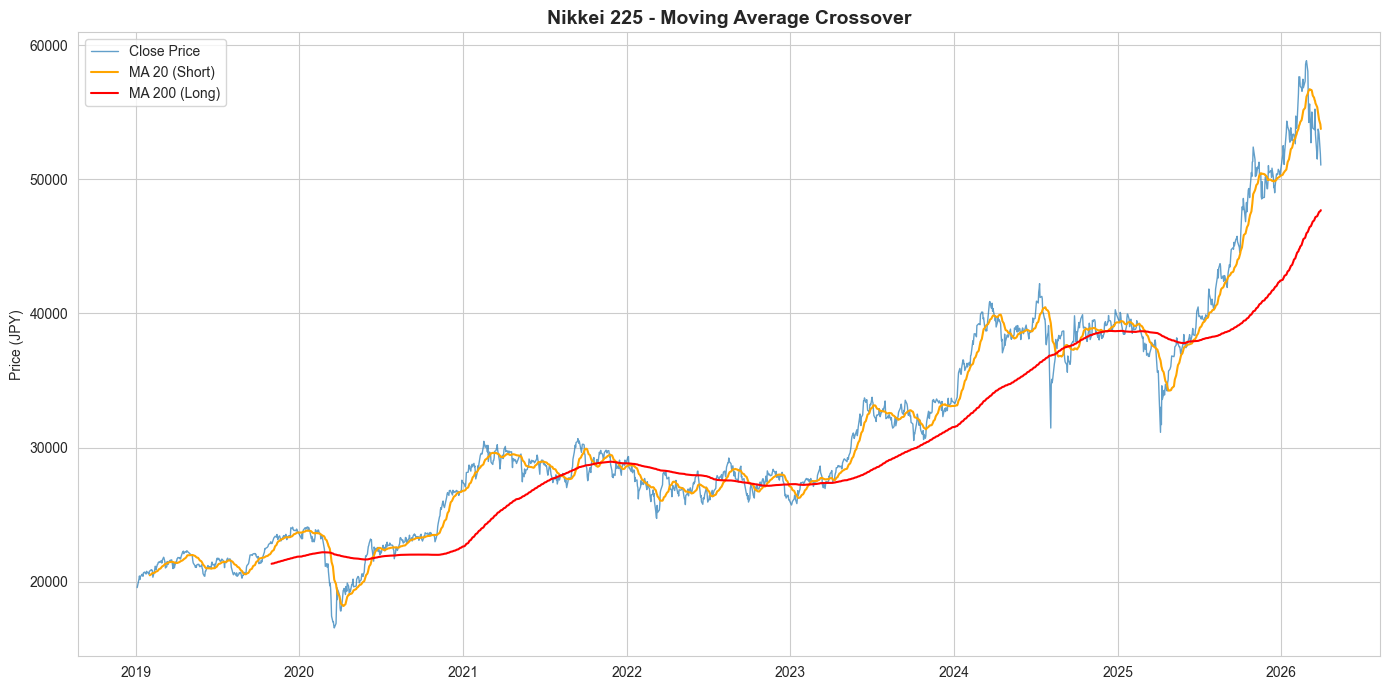

✓ 移動平均グラフ保存完了


In [3]:
# 移動平均グラフ
fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(nikkei.index, nikkei['Close'], label='Close Price', alpha=0.7, linewidth=1)
ax.plot(nikkei.index, nikkei['MA_20'], label='MA 20 (Short)', color='orange', linewidth=1.5)
ax.plot(nikkei.index, nikkei['MA_200'], label='MA 200 (Long)', color='red', linewidth=1.5)

ax.set_title('Nikkei 225 - Moving Average Crossover', fontsize=14, fontweight='bold')
ax.set_ylabel('Price (JPY)')
ax.legend(loc='upper left')

plt.tight_layout()
plt.savefig('moving_average.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ 移動平均グラフ保存完了")

## 3. 売買シグナルの生成（バックテスト）

ゴールデンクロス・デッドクロスを検出し、実際に売買を繰り返した場合のリターンを計算する。

ルール：
1. MA20 > MA200 になった日 → 買い（BUY）
2. MA20 < MA200 になった日 → 売り（SELL）
3. 各トレードのリターン（%）を記録

In [4]:
# シグナル生成
# MA20 > MA200 なら 1（買いポジション）、そうでなければ 0
nikkei['Signal'] = 0
nikkei.loc[nikkei['MA_20'] > nikkei['MA_200'], 'Signal'] = 1

# シグナルの変化点を検出（0→1 が BUY、1→0 が SELL）
nikkei['Signal_Change'] = nikkei['Signal'].diff()

# 売買ポイントを取得
buy_signals = nikkei[nikkei['Signal_Change'] == 1].copy()
sell_signals = nikkei[nikkei['Signal_Change'] == -1].copy()

print(f"【シグナル検出結果】")
print(f"  買いシグナル（ゴールデンクロス）: {len(buy_signals)} 回")
print(f"  売りシグナル（デッドクロス）:     {len(sell_signals)} 回")

【シグナル検出結果】
  買いシグナル（ゴールデンクロス）: 11 回
  売りシグナル（デッドクロス）:     10 回


## 4. トレードごとのリターンを計算
買い→売りの各ペアで「何%儲かった（損した）か」を算出する。

In [5]:
# トレードのペアを作成してリターンを計算
trades = []

# 買いと売りをペアにする
buy_dates = buy_signals.index.tolist()
sell_dates = sell_signals.index.tolist()

for buy_date in buy_dates:
    # この買いの後に来る最初の売りを探す
    future_sells = [s for s in sell_dates if s > buy_date]
    if future_sells:
        sell_date = future_sells[0]
        buy_price = nikkei.loc[buy_date, 'Close']
        sell_price = nikkei.loc[sell_date, 'Close']
        return_pct = (sell_price - buy_price) / buy_price * 100
        
        trades.append({
            'buy_date': buy_date,
            'sell_date': sell_date,
            'buy_price': buy_price,
            'sell_price': sell_price,
            'return_pct': return_pct,
            'holding_days': (sell_date - buy_date).days
        })

trades_df = pd.DataFrame(trades)

print(f"【トレード結果】")
print(f"  完了したトレード数: {len(trades_df)} 件")
print(f"  勝ちトレード:       {(trades_df['return_pct'] > 0).sum()} 件")
print(f"  負けトレード:       {(trades_df['return_pct'] <= 0).sum()} 件")
print(f"  勝率:               {(trades_df['return_pct'] > 0).mean() * 100:.1f}%")
print(f"  平均リターン:       {trades_df['return_pct'].mean():.2f}%")
print(f"  平均保有日数:       {trades_df['holding_days'].mean():.0f} 日")
print(f"\n【全トレード一覧】")
print(trades_df.to_string(index=False))

【トレード結果】
  完了したトレード数: 10 件
  勝ちトレード:       2 件
  負けトレード:       8 件
  勝率:               20.0%
  平均リターン:       2.07%
  平均保有日数:       143 日

【全トレード一覧】
  buy_date  sell_date    buy_price   sell_price  return_pct  holding_days
2019-10-31 2020-03-11 22927.039062 19416.060547  -15.313702           132
2020-06-12 2021-08-06 22305.480469 27820.039062   24.722886           420
2021-09-13 2021-10-22 30447.369141 28804.849609   -5.394619            39
2021-11-05 2021-12-13 29611.570312 28640.490234   -3.279394            38
2022-08-10 2022-10-04 27819.330078 26992.210938   -2.973181            55
2022-11-09 2022-12-29 27716.429688 26093.669922   -5.854866            50
2023-02-14 2024-08-19 27602.769531 37388.621094   35.452426           552
2024-09-05 2024-09-13 36657.089844 36581.761719   -0.205494             8
2024-10-11 2024-12-06 39605.800781 39091.171875   -1.299378            56
2024-12-11 2025-03-04 39372.230469 37331.179688   -5.183986            83


## 5. 統計検定（t検定）

### 問い
「この戦略の平均リターンは、本当にプラスなのか？たまたまではないか？」

### 仮説
- 帰無仮説（H₀）： 平均リターン = 0（この戦略に実力はない。儲かったのは偶然）
- 対立仮説（H₁）： 平均リターン ≠ 0（この戦略には統計的に有意な実力がある）

### 判定基準
- p値 < 0.05 → 帰無仮説を棄却 → **「偶然ではない」と結論**
- p値 >= 0.05 → 帰無仮説を棄却できない → 「偶然の可能性を排除できない」

In [6]:
# t検定の実施
returns = trades_df['return_pct'].values

# 1標本t検定：「平均リターンが0と異なるか」を検定
t_stat, p_value = stats.ttest_1samp(returns, 0)

print("=" * 60)
print("【t検定結果】 移動平均クロスオーバー戦略")
print("=" * 60)
print(f"  サンプルサイズ（トレード数）: {len(returns)}")
print(f"  平均リターン:                 {np.mean(returns):.4f}%")
print(f"  標準偏差:                     {np.std(returns, ddof=1):.4f}%")
print(f"  t統計量:                      {t_stat:.4f}")
print(f"  p値:                          {p_value:.6f}")
print("=" * 60)

if p_value < 0.05:
    print(f"\n✓ 結論：p値 = {p_value:.4f} < 0.05")
    print("  → 帰無仮説を棄却。")
    print("  → この戦略のリターンは統計的に有意。")
    print("  → 「偶然ではなく、実力がある」と95%の確信度で言える。")
else:
    print(f"\n✗ 結論：p値 = {p_value:.4f} >= 0.05")
    print("  → 帰無仮説を棄却できない。")
    print("  → このデータだけでは「実力がある」とは言い切れない。")
    print("  → より多くのデータや異なるパラメータでの検証が必要。")

【t検定結果】 移動平均クロスオーバー戦略
  サンプルサイズ（トレード数）: 10
  平均リターン:                 2.0671%
  標準偏差:                     15.5330%
  t統計量:                      0.4208
  p値:                          0.683754

✗ 結論：p値 = 0.6838 >= 0.05
  → 帰無仮説を棄却できない。
  → このデータだけでは「実力がある」とは言い切れない。
  → より多くのデータや異なるパラメータでの検証が必要。


## 6. 結果の可視化

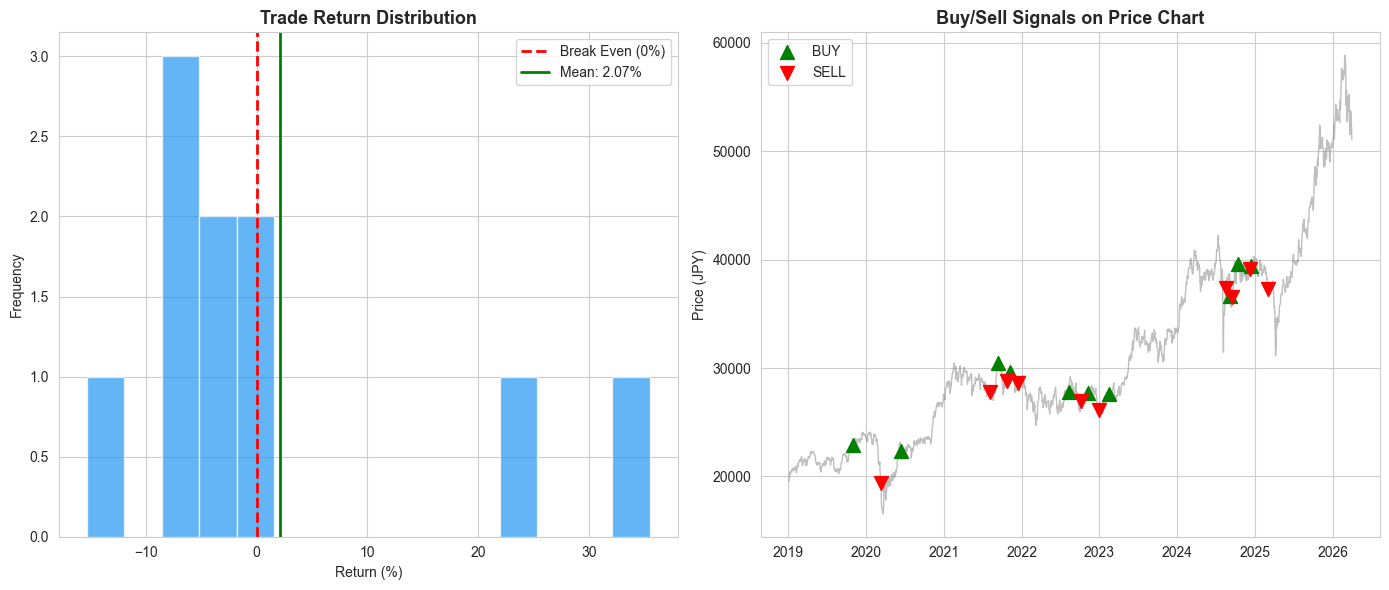

✓ バックテスト結果グラフ保存完了


In [7]:
# 結果の可視化
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 左：トレードリターンの分布
axes[0].hist(trades_df['return_pct'], bins=15, color='#2196F3', alpha=0.7, edgecolor='white')
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Break Even (0%)')
axes[0].axvline(x=trades_df['return_pct'].mean(), color='green', linestyle='-', linewidth=2, 
                label=f'Mean: {trades_df["return_pct"].mean():.2f}%')
axes[0].set_title('Trade Return Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Return (%)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# 右：売買ポイントを株価チャートに表示
axes[1].plot(nikkei.index, nikkei['Close'], color='gray', alpha=0.5, linewidth=1)
axes[1].scatter(trades_df['buy_date'], trades_df['buy_price'], 
               color='green', marker='^', s=100, label='BUY', zorder=5)
axes[1].scatter(trades_df['sell_date'], trades_df['sell_price'], 
               color='red', marker='v', s=100, label='SELL', zorder=5)
axes[1].set_title('Buy/Sell Signals on Price Chart', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Price (JPY)')
axes[1].legend()

plt.tight_layout()
plt.savefig('backtest_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ バックテスト結果グラフ保存完了")

## 7. まとめ

### 実装内容
1. 移動平均（MA20, MA200）を計算
2. ゴールデンクロス / デッドクロスで売買シグナルを生成
3. バックテストで各トレードのリターンを測定
4. t検定で戦略の有意性を統計的に検証

### ビジネスへの応用
- 施策効果の測定：「この施策は本当に効いたか？」をp値で判定
- A/Bテスト：「パターンAとBに差があるか？」を検定
- KPI分析：「売上の変化は偶然か、構造的か？」を統計で判断

### 次のステップ
Notebook 3 で因果推論（Granger テスト）を実装